In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from pathlib import Path

In [2]:
print(Path.cwd())

c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI


In [3]:
audio_dir = Path("ESC-50/audio")
metadata_path = Path("ESC-50/meta/esc50.csv")

In [4]:
print(audio_dir.exists())
print(metadata_path.exists())

True
True


In [5]:
df = pd.read_csv(metadata_path)

animals=["cat","dog","cow","sheep","frog"]

animal_df = df[df["category"].isin(animals)].copy()

print(animal_df.shape)
print(animal_df["category"].value_counts())

(200, 7)
category
dog      40
sheep    40
frog     40
cow      40
cat      40
Name: count, dtype: int64


In [6]:
def extract_mel_spectrogram(audio_path):
    y, sr = librosa.load(
        audio_path,
        sr=22050,
        duration=5.0
    )

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db

In [7]:
sample_path = audio_dir / animal_df.iloc[0]["filename"]

mel = extract_mel_spectrogram(sample_path)

print("Mel Spectrogram shape:", mel.shape)

Mel Spectrogram shape: (128, 216)


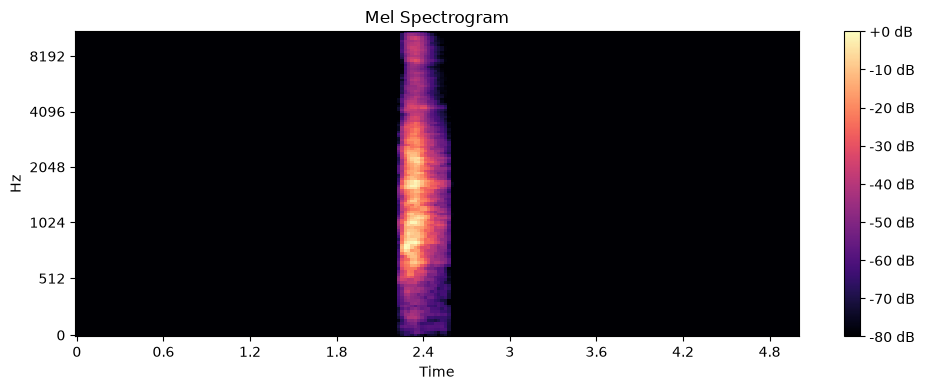

In [8]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mel,
    sr=22050,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

In [9]:
X_mel = []
y_labels = []
folds = []

for _, row in animal_df.iterrows():

    audio_path = audio_dir / row["filename"]

    mel = extract_mel_spectrogram(audio_path)

    X_mel.append(mel)
    y_labels.append(row["category"])
    folds.append(row["fold"])

X_mel = np.array(X_mel)
y_labels = np.array(y_labels)
folds = np.array(folds)

print("X shape:", X_mel.shape)
print("y shape:", y_labels.shape)
print("folds shape:", folds.shape)

X shape: (200, 128, 216)
y shape: (200,)
folds shape: (200,)


In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_labels)

print("Sınıflar:", label_encoder.classes_)
print("İlk 10 label:", y_encoded[:10])

Sınıflar: ['cat' 'cow' 'dog' 'frog' 'sheep']
İlk 10 label: [2 2 4 3 3 1 3 3 3 3]


In [11]:
train_mask = np.isin(folds, [3, 4, 5])
val_mask = folds == 2
test_mask = folds == 1

X_train = X_mel[train_mask]
X_val = X_mel[val_mask]
X_test = X_mel[test_mask]

y_train = y_encoded[train_mask]
y_val = y_encoded[val_mask]
y_test = y_encoded[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (120, 128, 216) (120,)
Validation: (40, 128, 216) (40,)
Test: (40, 128, 216) (40,)


In [12]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (120, 128, 216, 1)
Validation: (40, 128, 216, 1)
Test: (40, 128, 216, 1)


In [13]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model = Sequential([
    
    Conv2D(
        16,
        (3, 3),
        activation="relu",
        input_shape=(128, 216, 1)
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        5,
        activation="softmax"
    )
])

model.summary()

c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 214, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 107, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 105, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,541 (99.77 KB)

 Trainable params: 25,541 (99.77 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    X_train,
    y_train,
    validation_data = (X_val, y_val),
    epochs=50,
    batch_size = 16,
    callbacks = [early_stopping],
    verbose = 1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.2250 - loss: 4.6169 - val_accuracy: 0.2000 - val_loss: 1.7555
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.2083 - loss: 1.8677 - val_accuracy: 0.2000 - val_loss: 1.6159
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.1750 - loss: 1.6631 - val_accuracy: 0.2000 - val_loss: 1.5787
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.2083 - loss: 1.6289 - val_accuracy: 0.2250 - val_loss: 1.6031
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.1917 - loss: 1.6399 - val_accuracy: 0.2500 - val_loss: 1.6140
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.2500 - loss: 1.5555 - val_accuracy: 0.2000 - val_loss: 1.6777
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.2667 - loss: 1.6397 - val_accuracy: 0.2750 - val_loss: 1.5720
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.2417 - loss: 1.5890 - val_accuracy: 0.3000 - val_loss:

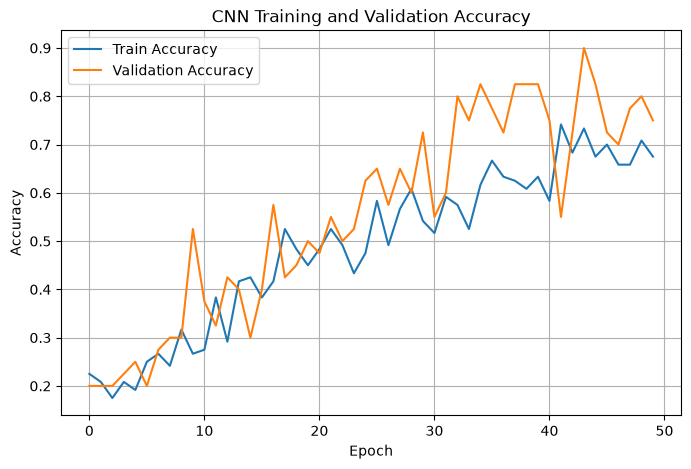

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

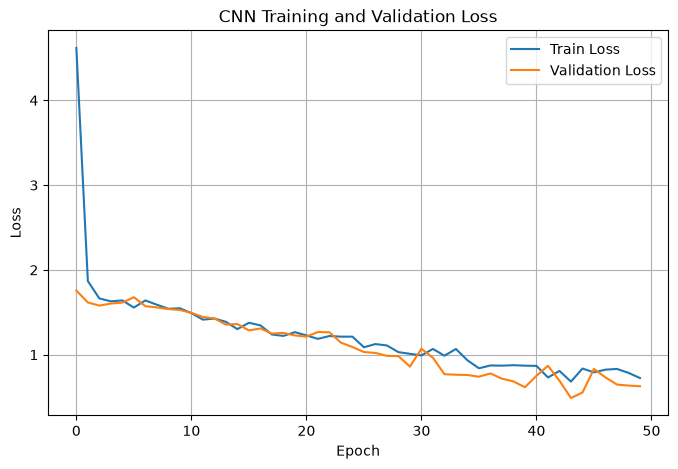

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [20]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = np.min(history.history["val_loss"])
best_val_accuracy = history.history["val_accuracy"][best_epoch - 1]

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Validation accuracy at best epoch:", best_val_accuracy)

Best epoch: 44
Best validation loss: 0.4890018105506897
Validation accuracy at best epoch: 0.8999999761581421


In [21]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.5703
Test Accuracy: 0.8250


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


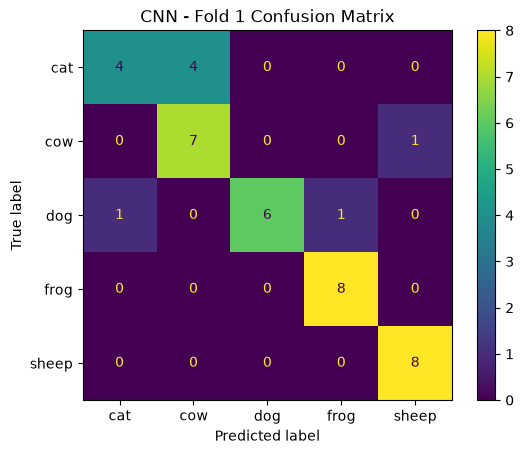

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Her ses için 5 sınıfın olasılıklarını al
y_prob = model.predict(X_test)

# En yüksek olasılığa sahip sınıfı seç
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3, 4]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("CNN - Fold 1 Confusion Matrix")
plt.show()

In [28]:
def create_cnn():

    model = Sequential([

        Conv2D(
            16,
            (3, 3),
            activation="relu",
            input_shape=(128, 216, 1)
        ),
        MaxPooling2D((2, 2)),

        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        GlobalAveragePooling2D(),

        Dense(32, activation="relu"),

        Dropout(0.4),

        Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
test_model = create_cnn()
test_model.summary()

c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 214, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 107, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 105, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,541 (99.77 KB)

 Trainable params: 25,541 (99.77 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
import random
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

cnn_fold_results = []
cnn_all_true = []
cnn_all_pred = []

for test_fold in range(1, 6):

    # Test fold'dan sonraki fold validation olsun
    val_fold = (test_fold % 5) + 1

    train_mask = (folds != test_fold) & (folds != val_fold)
    val_mask = folds == val_fold
    test_mask = folds == test_fold

    X_train_fold = X_mel_norm[train_mask][..., np.newaxis]
    X_val_fold = X_mel_norm[val_mask][..., np.newaxis]
    X_test_fold = X_mel_norm[test_mask][..., np.newaxis]

    y_train_fold = y_encoded[train_mask]
    y_val_fold = y_encoded[val_mask]
    y_test_fold = y_encoded[test_mask]

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    # Her fold için yepyeni CNN
    fold_model = create_cnn()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    history=fold_model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=60,
        batch_size=16,
        callbacks=[early_stopping],
        verbose=0
    )

    # Test
    test_loss, test_accuracy = fold_model.evaluate(
        X_test_fold,
        y_test_fold,
        verbose=0
    )

    # Tahminleri kaydet
    probabilities = fold_model.predict(
        X_test_fold,
        verbose=0
    )

    predictions = np.argmax(probabilities, axis=1)

    cnn_fold_results.append(test_accuracy)
    cnn_all_true.extend(y_test_fold)
    cnn_all_pred.extend(predictions)

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_val_loss = np.min(history.history["val_loss"])
    best_val_acc = history.history["val_accuracy"][best_epoch - 1]

    print(
        f"Fold {test_fold} | "
        f"Best Epoch: {best_epoch} | "
        f"Best Val Acc: {best_val_acc:.3f} | "
        f"Test Acc: {test_accuracy:.3f}"
    )
    print(
        f"Fold {test_fold} | "
        f"Validation Fold {val_fold} | "
        f"Accuracy: {test_accuracy:.3f}"
    )

print("\n--------------------")
print(
    f"CNN Mean Accuracy: "
    f"{np.mean(cnn_fold_results):.3f}"
)
print(
    f"CNN Std: "
    f"{np.std(cnn_fold_results):.3f}"
)

c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 | Best Epoch: 59 | Best Val Acc: 0.575 | Test Acc: 0.450
Fold 1 | Validation Fold 2 | Accuracy: 0.450
Fold 2 | Best Epoch: 37 | Best Val Acc: 0.475 | Test Acc: 0.475
Fold 2 | Validation Fold 3 | Accuracy: 0.475
Fold 3 | Best Epoch: 59 | Best Val Acc: 0.650 | Test Acc: 0.525
Fold 3 | Validation Fold 4 | Accuracy: 0.525
Fold 4 | Best Epoch: 28 | Best Val Acc: 0.525 | Test Acc: 0.450
Fold 4 | Validation Fold 5 | Accuracy: 0.450
Fold 5 | Best Epoch: 7 | Best Val Acc: 0.350 | Test Acc: 0.275
Fold 5 | Validation Fold 1 | Accuracy: 0.275

--------------------
CNN Mean Accuracy: 0.435
CNN Std: 0.085


In [27]:
X_mel_norm = (X_mel + 80.0) / 80.0

X_mel_norm = np.clip(
    X_mel_norm,
    0.0,
    1.0
)

print("Min:", X_mel_norm.min())
print("Max:", X_mel_norm.max())
print("Shape:", X_mel_norm.shape)

Min: 0.0
Max: 1.0
Shape: (200, 128, 216)
